# MIN3P advective-transport sweep — flow velocity vs driving head

A second worked example of a MIN3P sweep run through Omphalos (`velocity_sweep.yaml`), complementing the `dissol_sweep` example. Where that one swept a *chemical* boundary condition, this sweeps a *flow* parameter.

**Problem** (`reactran/MCD-2-advection`): a high-pH water (pH 10) is injected into a 1-D column initially at pH 6. A hydraulic-head gradient between the inflow (head = 1.0) and outflow boundaries drives the water through by advection. We sweep the **outflow-boundary head** over four values, which sets the gradient and hence the Darcy velocity, and watch how far the pH front migrates.

This exercises flow-parameter modification and the `.vel` (Darcy velocity) output, and reproduces Darcy's law as a by-product.

In [1]:
# results.nc is a sweep output and is not in the repository, so say what to run rather
# than failing inside netCDF4 with an absolute path and no reason.
from pathlib import Path

if not (Path.cwd() / 'results.nc').exists():
    raise FileNotFoundError(
        'results.nc not found — run the sweep in the Reproduce section of README.md '
        'first (python -m min3p.main velocity_sweep.yaml records.pkl).'
    )


In [2]:
from pathlib import Path

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

style_path = Path.home() / 'Python' / 'mpl_styles' / 'publication.mplstyle'
if style_path.exists():
    plt.style.use(str(style_path))

RESULTS = Path('results.nc')                 # written by velocity_sweep.yaml
OUTFLOW_HEAD = [0.99, 0.97, 0.94, 0.90]      # swept outflow head, by file_num
INFLOW_HEAD = 1.0                            # fixed inflow head (from the template)
GRADIENT = [(INFLOW_HEAD - h) for h in OUTFLOW_HEAD]   # head drop over the 1 m column

## Load results

`gsm` holds the master variables (including pH); `vel` holds the Darcy velocity field (`vx, vy, vz`) on the cell faces. The column runs along `x`.

In [3]:
gsm = xr.open_dataset(RESULTS, group='gsm')   # master variables (pH, ...)
vel = xr.open_dataset(RESULTS, group='vel')   # Darcy velocity field

x = gsm['x'].values
print('gsm dims:', dict(gsm.sizes))
print('vel dims:', dict(vel.sizes))
# Output index 4 corresponds to t = 40 days in this template's output schedule
T_INDEX, T_DAYS = 4, 40
gsm

gsm dims: {'file_num': 4, 'output': 9, 'x': 101, 'y': 1, 'z': 1}
vel dims: {'file_num': 4, 'output': 1, 'x': 100, 'y': 1, 'z': 1}


<xarray.Dataset> Size: 292kB
Dimensions:                   (file_num: 4, output: 9, x: 101, y: 1, z: 1)
Coordinates:
  * x                         (x) float64 808B 0.0 0.01 0.02 ... 0.98 0.99 1.0
  * y                         (y) float64 8B 0.0
  * z                         (z) float64 8B 0.0
  * output                    (output) int64 72B 0 1 2 3 4 5 6 7 8
  * file_num                  (file_num) int64 32B 0 1 2 3
Data variables:
    pH                        (file_num, output, x, y, z) float64 29kB ...
    ionic strength            (file_num, output, x, y, z) float64 29kB ...
    C-Alk [eq_per_L]          (file_num, output, x, y, z) float64 29kB ...
    NC-Alk [eq_per_L]         (file_num, output, x, y, z) float64 29kB ...
    Alk [eq_per_L]            (file_num, output, x, y, z) float64 29kB ...
    C-Alk [mg_per_L CaCO_3]   (file_num, output, x, y, z) float64 29kB ...
    NC-Alk [mg_per_L CaCO_3]  (file_num, output, x, y, z) float64 29kB ...
    Alk [mg_per_L CaCO_3]     (file_num, output, x, y, z) float64 29kB ...
    temperature               (file_num, output, x, y, z) float64 29kB ...
    charge bal [%]            (file_num, output, x, y, z) float64 29kB ...

## Front migration and Darcy's law

**A** — the pH front after 40 days: the injected high-pH water penetrates further as the driving head gradient (and hence velocity) increases.
**B** — the peak Darcy velocity scales linearly with the head gradient, with slope equal to the hydraulic conductivity — i.e. Darcy's law, v = K·(dh/dx), recovered directly from the sweep.

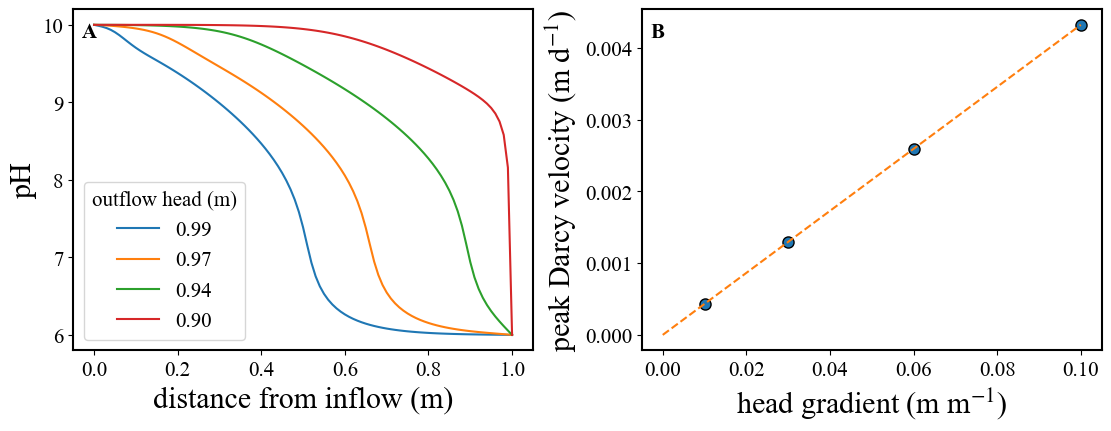

fitted slope (hydraulic conductivity) = 0.0432 m/d


In [4]:
def ph_profile(i):
    return gsm['pH'].isel(output=T_INDEX, file_num=i).squeeze(drop=True).values

def peak_darcy(i):
    return float(np.abs(vel['vx'].isel(output=0, file_num=i).squeeze(drop=True)).max())

fig, (axA, axB) = plt.subplots(1, 2, figsize=(11, 4.2), constrained_layout=True)

# A: pH front vs distance, one line per outflow head
for i, h in enumerate(OUTFLOW_HEAD):
    axA.plot(x, ph_profile(i), label=f'{h:.2f}')
axA.set_xlabel('distance from inflow (m)')
axA.set_ylabel('pH')
axA.legend(title='outflow head (m)')
axA.text(0.02, 0.96, 'A', transform=axA.transAxes, fontweight='bold', va='top')

# B: peak Darcy velocity vs head gradient (Darcy's law)
v = [peak_darcy(i) for i in range(len(OUTFLOW_HEAD))]
axB.plot(GRADIENT, v, marker='o', linestyle='none')
# line through the origin fitted to the points (slope ~ hydraulic conductivity)
slope = np.polyfit(GRADIENT, v, 1)[0]
g = np.array([0] + GRADIENT)
axB.plot(g, slope * g, linestyle='--')
axB.set_xlabel('head gradient (m m$^{-1}$)')
axB.set_ylabel('peak Darcy velocity (m d$^{-1}$)')
axB.text(0.02, 0.96, 'B', transform=axB.transAxes, fontweight='bold', va='top')

fig.savefig('velocity_sweep.png', dpi=300, bbox_inches='tight')
plt.show()
print(f'fitted slope (hydraulic conductivity) = {slope:.4g} m/d')

## Summary

One flow parameter, four runs: the pH front advances further with a steeper head gradient, and the recovered velocity–gradient relationship is linear through the origin — Darcy's law, with the slope equal to the medium's hydraulic conductivity. Both the transport response and the velocity field (`.vel`) come straight out of `results.nc`.

In [5]:
import pandas as pd
rows = []
for i, h in enumerate(OUTFLOW_HEAD):
    ph = ph_profile(i)
    front = float(x[ph > 7.0].max()) if (ph > 7.0).any() else 0.0
    rows.append({
        'outflow head (m)':          h,
        'head gradient (m/m)':       round(GRADIENT[i], 3),
        'peak Darcy vel. (m/d)':     peak_darcy(i),
        f'pH>7 front @ {T_DAYS} d (m)': round(front, 3),
    })
pd.DataFrame(rows)

,outflow head (m),head gradient (m/m),peak Darcy vel. (m/d),pH>7 front @ 40 d (m)
0,0.99,0.01,0.000432,0.51
1,0.97,0.03,0.001296,0.66
2,0.94,0.06,0.002592,0.89
3,0.90,0.10,0.004320,0.99
